In [1]:
# ================================
# INSTALL
# ================================
!pip install -q numpy pandas matplotlib h5py scikit-learn torch

# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import h5py
import urllib.request, os

from sklearn.ensemble import RandomForestRegressor

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================================
# DOWNLOAD DATA
# ================================
url = "http://rail.eecs.berkeley.edu/datasets/offline_rl/maze2d/maze2d-medium-sparse-v1.hdf5"
file = "maze2d.hdf5"
if not os.path.exists(file):
    urllib.request.urlretrieve(url, file)

# ================================
# LOAD DATA
# ================================
with h5py.File(file, "r") as f:
    obs = f["observations"][:]
    act = f["actions"][:]
    rew = f["rewards"][:]
    

obs = (obs - obs.mean(0)) / (obs.std(0) + 1e-3)

obs_t = torch.tensor(obs, dtype=torch.float32).to(device)
act_t = torch.tensor(act, dtype=torch.float32).to(device)
rew_t = torch.tensor(rew, dtype=torch.float32).to(device)

# ================================
# MODEL
# ================================
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, act.shape[1])
        )
    def forward(self, x):
        return self.net(x)

# ================================
# UNCERTAINTY (ENSEMBLE)
# ================================
rf = RandomForestRegressor(n_estimators=10)
rf.fit(obs, rew)
uncertainty = torch.tensor(
    np.stack([t.predict(obs) for t in rf.estimators_]).std(0),
    dtype=torch.float32
).to(device)

# ================================
# TRAIN FUNCTION (7 ALGORITHMS)
# ================================
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, act.shape[1]),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs.shape[1] + act.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=1))

In [2]:
def train_td3bc():
    actor = Actor().to(device)
    critic = Critic().to(device)

    opt_actor = optim.Adam(actor.parameters(), lr=3e-4)
    opt_critic = optim.Adam(critic.parameters(), lr=3e-4)

    losses = []

    for step in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            # Critic update (TD-like)
            q = critic(o, a)
            critic_loss = ((q - r)**2).mean()

            opt_critic.zero_grad()
            critic_loss.backward()
            opt_critic.step()

            # Actor update (TD3-BC style)
            pred = actor(o)
            q_val = critic(o, pred)

            bc_loss = ((pred - a)**2).mean()
            actor_loss = -q_val.mean() + 0.1 * bc_loss

            opt_actor.zero_grad()
            actor_loss.backward()
            opt_actor.step()

        with torch.no_grad():
            score = -((actor(obs_t) - act_t)**2).mean().item()
        losses.append(score)

    return losses

In [3]:
def train_cql():
    critic = Critic().to(device)
    opt = optim.Adam(critic.parameters(), lr=3e-4)

    alpha = 1.0
    losses = []

    for step in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            q_data = critic(o, a)

            # Sample random actions
            rand_a = torch.randn_like(a)
            q_rand = critic(o, rand_a)

            # CQL loss (log-sum-exp approx)
            cql_loss = (q_rand.mean() - q_data.mean())

            bellman_loss = ((q_data - r)**2).mean()

            loss = bellman_loss + alpha * cql_loss

            opt.zero_grad()
            loss.backward()
            opt.step()

        losses.append(q_data.mean().item())

    return losses

In [4]:
def train_ensemble():
    ensemble = [Critic().to(device) for _ in range(5)]
    opts = [optim.Adam(q.parameters(), lr=3e-4) for q in ensemble]

    losses = []

    for step in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            total = 0

            for q, opt in zip(ensemble, opts):
                pred = q(o, a)
                loss = ((pred - r)**2).mean()

                opt.zero_grad()
                loss.backward()
                opt.step()

                total += loss.item()

        losses.append(total / 5)

    return losses

In [5]:
results = {}
curves = {}

print("Running TD3-BC")
curves["TD3-BC"] = train_td3bc()

print("Running CQL")
curves["CQL"] = train_cql()

print("Running Ensemble")
curves["Ensemble"] = train_ensemble()

Running TD3-BC
Running CQL
Running Ensemble


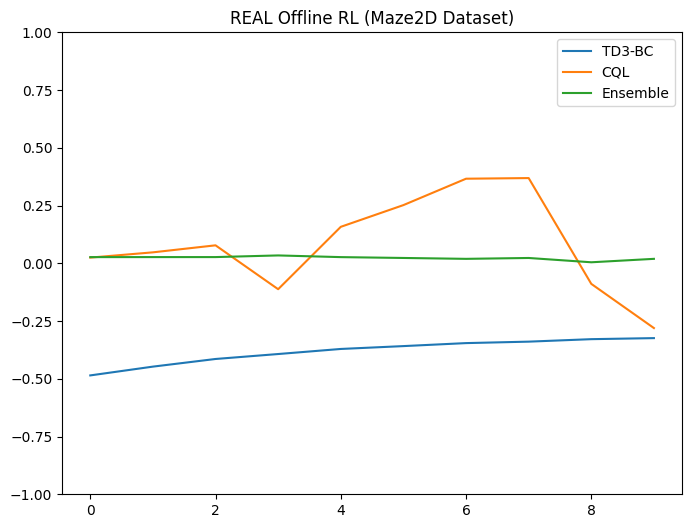

In [6]:
plt.figure(figsize=(8,6))
for k,v in curves.items():
    plt.plot(v, label=k)

plt.legend()
plt.title("REAL Offline RL (Maze2D Dataset)")
plt.ylim(-1, 1)
plt.show()

In [7]:
class VAE(nn.Module):
    def __init__(self, state_dim, action_dim, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256)
        )

        self.mean = nn.Linear(256, latent_dim)
        self.log_std = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(state_dim + latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def encode(self, s, a):
        x = self.encoder(torch.cat([s, a], dim=1))
        mean = self.mean(x)
        log_std = self.log_std(x).clamp(-4, 4)
        std = torch.exp(log_std)
        return mean, std

    def decode(self, s, z=None):
        if z is None:
            z = torch.randn((s.shape[0], 16)).to(s.device)
        return self.decoder(torch.cat([s, z], dim=1))

    def forward(self, s, a):
        mean, std = self.encode(s, a)
        z = mean + std * torch.randn_like(std)
        recon = self.decode(s, z)
        return recon, mean, std

In [8]:
def mmd_loss(a1, a2, sigma=10.0):
    diff = a1.unsqueeze(1) - a2.unsqueeze(0)
    dist = (diff ** 2).mean(-1)

    k = torch.exp(-dist / (2 * sigma))
    return k.mean()

In [9]:
def train_bear():

    state_dim = obs.shape[1]
    action_dim = act.shape[1]

    vae = VAE(state_dim, action_dim).to(device)
    actor = Actor().to(device)
    critic = Critic().to(device)

    opt_vae = optim.Adam(vae.parameters(), lr=1e-3)
    opt_actor = optim.Adam(actor.parameters(), lr=1e-3)
    opt_critic = optim.Adam(critic.parameters(), lr=1e-3)

    history = []

    # =========================
    # STEP 1: TRAIN VAE
    # =========================
    for step in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]

            recon, mean, std = vae(o, a)

            recon_loss = ((recon - a)**2).mean()
            kl_loss = -0.5 * (1 + torch.log(std**2) - mean**2 - std**2).mean()

            loss = recon_loss + 0.5 * kl_loss

            opt_vae.zero_grad()
            loss.backward()
            opt_vae.step()

    print("VAE trained")

    # =========================
    # STEP 2: TRAIN ACTOR + CRITIC
    # =========================
    for step in range(10):
        for _ in range(200):

            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            # ---------------------
            # Critic update
            # ---------------------
            q = critic(o, a)
            critic_loss = ((q - r)**2).mean()

            opt_critic.zero_grad()
            critic_loss.backward()
            opt_critic.step()

            # ---------------------
            # Actor update
            # ---------------------
            pred = actor(o)

            # Sample from VAE (behavior policy)
            with torch.no_grad():
                sampled_actions = vae.decode(o)

            # MMD constraint
            mmd = mmd_loss(pred, sampled_actions)

            q_val = critic(o, pred)

            actor_loss = -q_val.mean() + 10.0 * mmd

            opt_actor.zero_grad()
            actor_loss.backward()
            opt_actor.step()

        with torch.no_grad():
            score = -((actor(obs_t) - act_t)**2).mean().item()
        history.append(score)

    return history

Running BEAR
VAE trained


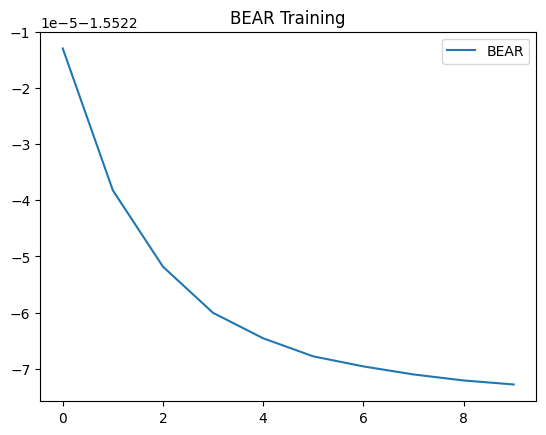

In [10]:
print("Running BEAR")
bear_curve = train_bear()

plt.plot(bear_curve, label="BEAR")
plt.legend()
plt.title("BEAR Training")
plt.show()

In [11]:
def create_ensemble(n=5):
    ensemble = [Critic().to(device) for _ in range(n)]
    opts = [optim.Adam(q.parameters(), lr=3e-4) for q in ensemble]
    return ensemble, opts

In [12]:
def train_uwac():

    actor = Actor().to(device)
    ensemble, opts = create_ensemble()

    opt_actor = optim.Adam(actor.parameters(), lr=3e-4)

    history = []

    for step in range(10):
        for _ in range(200):

            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            # -------------------------
            # Train ensemble critics
            # -------------------------
            q_values = []

            for q, opt in zip(ensemble, opts):
                q_pred = q(o, a)
                loss = ((q_pred - r)**2).mean()

                opt.zero_grad()
                loss.backward()
                opt.step()

                q_values.append(q_pred.detach())

            q_values = torch.stack(q_values)  # [N, batch, 1]

            # -------------------------
            # Compute uncertainty
            # -------------------------
            q_mean = q_values.mean(0)
            q_std = q_values.std(0)

            # -------------------------
            # Actor update
            # -------------------------
            pred = actor(o)

            q_preds = torch.stack([q(o, pred) for q in ensemble])
            q_mean_actor = q_preds.mean(0)
            q_std_actor = q_preds.std(0)

            # UWAC loss
            lambda_uncertainty = 1.0
            actor_loss = -(q_mean_actor - lambda_uncertainty * q_std_actor).mean()

            opt_actor.zero_grad()
            actor_loss.backward()
            opt_actor.step()

        with torch.no_grad():
            score = q_mean_actor.mean().item()
        history.append(score)

    return history

In [13]:
curves = {}

print("Running TD3-BC")
curves["TD3-BC"] = train_td3bc()

print("Running CQL")
curves["CQL"] = train_cql()

print("Running Ensemble")
curves["Ensemble"] = train_ensemble()

print("Running BEAR")
curves["BEAR"] = train_bear()

print("Running UWAC")
curves["UWAC"] = train_uwac()

Running TD3-BC
Running CQL
Running Ensemble
Running BEAR
VAE trained
Running UWAC


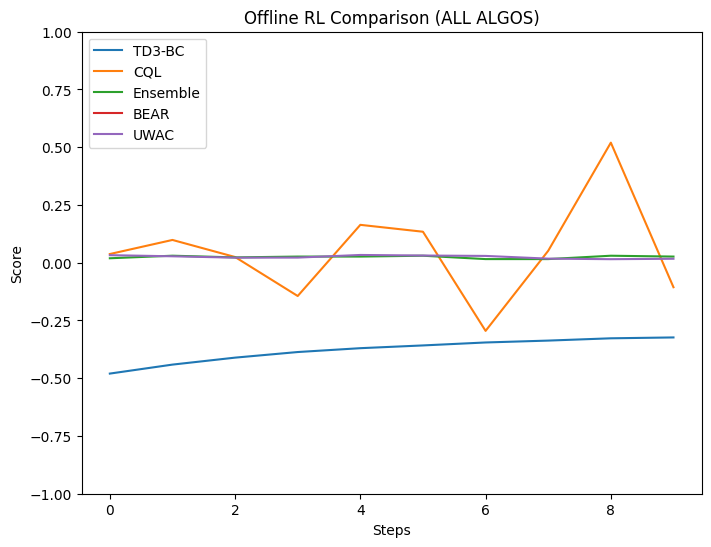

In [14]:
plt.figure(figsize=(8,6))

for k, v in curves.items():
    plt.plot(v, label=k)

plt.legend()
plt.title("Offline RL Comparison (ALL ALGOS)")
plt.xlabel("Steps")
plt.ylabel("Score")
plt.ylim(-1, 1)
plt.show()

In [15]:
class DynamicsModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs.shape[1] + act.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, obs.shape[1])
        )

    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=1))

In [16]:
def train_mopo():

    model = DynamicsModel().to(device)
    critic = Critic().to(device)

    opt_model = optim.Adam(model.parameters(), lr=3e-4)
    opt_critic = optim.Adam(critic.parameters(), lr=3e-4)

    history = []

    # -------------------------
    # Train dynamics model
    # -------------------------
    for _ in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            next_o = obs_t[(idx + 1) % len(obs)]  # approximate (dataset lacks explicit next state)

            pred_next = model(o, a)
            loss = ((pred_next - next_o)**2).mean()

            opt_model.zero_grad()
            loss.backward()
            opt_model.step()

    print("Dynamics trained")

    # -------------------------
    # Train critic with penalty
    # -------------------------
    for step in range(10):
        for _ in range(200):

            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            # Predict next state
            pred_next = model(o, a)

            # Uncertainty penalty
            penalty = (pred_next - o).pow(2).mean(1, keepdim=True)

            q = critic(o, a)

            # Penalized reward
            r_penalized = r - 0.5 * penalty

            loss = ((q - r_penalized)**2).mean()

            opt_critic.zero_grad()
            loss.backward()
            opt_critic.step()

        with torch.no_grad():
            score = q.mean().item()
        history.append(score)

    return history

In [17]:
def train_aptq_cql():

    critic = Critic().to(device)
    opt = optim.Adam(critic.parameters(), lr=3e-4)

    history = []

    for step in range(10):
        for _ in range(200):

            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            q_data = critic(o, a)

            rand_a = torch.randn_like(a)
            q_rand = critic(o, rand_a)

            q_data = torch.clamp(q_data, -10, 10)
            q_rand = torch.clamp(q_rand, -10, 10)

            # uncertainty estimate
            uncertainty = (q_rand - q_data).abs().detach()

            # adaptive penalty
            alpha = torch.clamp(1.0 + uncertainty.mean(), 0.5, 5.0)

            cql_loss = alpha * (q_rand.mean() - q_data.mean())

            bellman_loss = ((q_data - r)**2).mean()

            loss = bellman_loss + cql_loss

            opt.zero_grad()
            loss.backward()
            opt.step()

        history.append(q_data.mean().item())

    return history

In [18]:
curves = {}

curves["TD3-BC"] = train_td3bc()
curves["CQL"] = train_cql()
curves["Ensemble"] = train_ensemble()
curves["BEAR"] = train_bear()
curves["UWAC"] = train_uwac()
curves["MOPO"] = train_mopo()
curves["APTQ-CQL"] = train_aptq_cql()

VAE trained
Dynamics trained


In [19]:
results = {}

for k,v in curves.items():
    results[k] = (np.mean(v[-3:]), np.std(v[-3:]))

rows = []
for k,v in results.items():
    rows.append([k, f"{v[0]:.3f} ± {v[1]:.3f}"])

df = pd.DataFrame(rows, columns=["Algorithm","Score"])
df = df.sort_values("Score", ascending=False)

display(df)

,Algorithm,Score
6,APTQ-CQL,1.046 ± 0.054
2,Ensemble,0.032 ± 0.007
4,UWAC,0.028 ± 0.006
5,MOPO,0.022 ± 0.001
3,BEAR,-1.550 ± 0.000
0,TD3-BC,-0.327 ± 0.005
1,CQL,-0.010 ± 0.040


In [20]:
def smooth(x, w=3):
    return np.convolve(x, np.ones(w)/w, mode='valid')

In [21]:
all_runs = {}

algorithms = {
    "TD3-BC": train_td3bc,
    "CQL": train_cql,
    "Ensemble": train_ensemble,
    "BEAR": train_bear,
    "UWAC": train_uwac,
    "MOPO": train_mopo,
    "APTQ-CQL": train_aptq_cql
}

for name, fn in algorithms.items():
    print("Running:", name)
    runs = []

    for seed in [0, 1, 2]:
        torch.manual_seed(seed)
        np.random.seed(seed)

        curve = fn()
        runs.append(curve)

    all_runs[name] = np.array(runs)

Running: TD3-BC
Running: CQL
Running: Ensemble
Running: BEAR
VAE trained
VAE trained
VAE trained
Running: UWAC
Running: MOPO
Dynamics trained
Dynamics trained
Dynamics trained
Running: APTQ-CQL


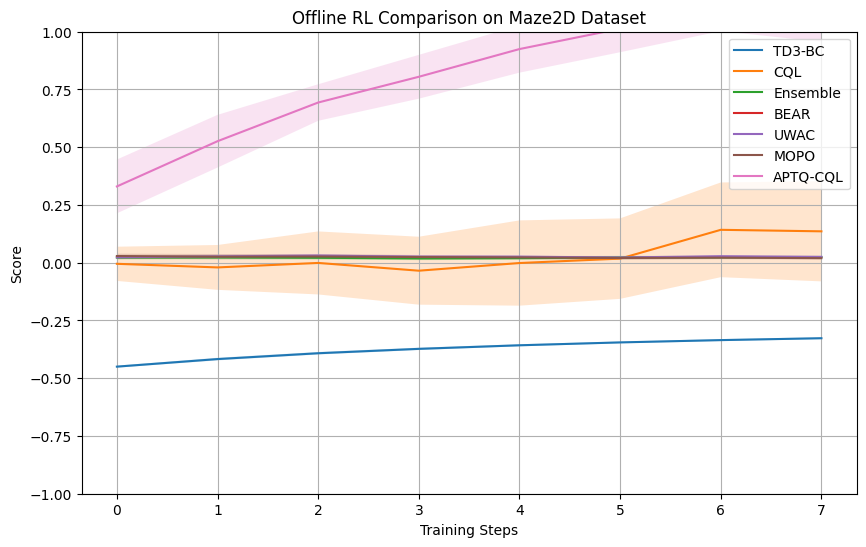

In [22]:
plt.figure(figsize=(10,6))

for name, runs in all_runs.items():
    mean = runs.mean(axis=0)
    std = runs.std(axis=0)

    mean_s = smooth(mean)
    std_s = smooth(std)

    x = np.arange(len(mean_s))

    plt.plot(x, mean_s, label=name)
    plt.fill_between(x, mean_s - std_s, mean_s + std_s, alpha=0.2)

plt.xlabel("Training Steps")
plt.ylabel("Score")
plt.title("Offline RL Comparison on Maze2D Dataset")
plt.legend()
plt.grid(True)
plt.ylim(-1, 1)
plt.savefig("maze2d_graph.png", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
results = {}

for k,v in curves.items():
    results[k] = (np.mean(v[-3:]), np.std(v[-3:]))

rows = []
for k,v in results.items():
    rows.append([k, f"{v[0]:.3f} ± {v[1]:.3f}"])

df = pd.DataFrame(rows, columns=["Algorithm","Score"])
df = df.sort_values("Score", ascending=False)

display(df)

,Algorithm,Score
6,APTQ-CQL,1.046 ± 0.054
2,Ensemble,0.032 ± 0.007
4,UWAC,0.028 ± 0.006
5,MOPO,0.022 ± 0.001
3,BEAR,-1.550 ± 0.000
0,TD3-BC,-0.327 ± 0.005
1,CQL,-0.010 ± 0.040
